In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import cv2.ximgproc as xip

def show(img, gray=False):
    plt.figure(figsize=(6,6))
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

stereoRectificationMap = "stereoMap.xml"

cv_file = cv2.FileStorage()
cv_file.open(stereoRectificationMap, cv2.FileStorage_READ)

Q = cv_file.getNode('q_matrix').mat()
stereoMapL_x = cv_file.getNode('stereoMapL_x').mat()
stereoMapL_y = cv_file.getNode('stereoMapL_y').mat()
stereoMapR_x = cv_file.getNode('stereoMapR_x').mat()
stereoMapR_y = cv_file.getNode('stereoMapR_y').mat()
roiL = cv_file.getNode('roiL').mat()
roiR = cv_file.getNode('roiR').mat()

# ROI comum
x = max(roiL[0], roiR[0])
y = max(roiL[1], roiR[1])
w = min(roiL[0] + roiL[2], roiR[0] + roiR[2]) - x
h = min(roiL[1] + roiL[3], roiR[1] + roiR[3]) - y
common_roi = (int(x), int(y), int(w), int(h))

/tmp/ipykernel_7251/1736376954.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  common_roi = (int(x), int(y), int(w), int(h))


In [12]:
imgL = cv2.imread("leftImages/6.jpg")
imgR = cv2.imread("rightImages/6.jpg")

grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

rect_grayL = cv2.remap(grayL, stereoMapL_x, stereoMapL_y,
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

rect_grayR = cv2.remap(grayR, stereoMapR_x, stereoMapR_y,
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

print("Rectified shape:", rect_grayL.shape)

Rectified shape: (640, 480)


In [13]:
# ==============================
# TRUQUE 1 — CLAHE
# ==============================

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
rect_grayL = clahe.apply(rect_grayL)
rect_grayR = clahe.apply(rect_grayR)

In [14]:
# ==============================
# TRUQUE 2 — Gaussian blur leve
# ==============================

rect_grayL = cv2.GaussianBlur(rect_grayL, (3,3), 0)
rect_grayR = cv2.GaussianBlur(rect_grayR, (3,3), 0)

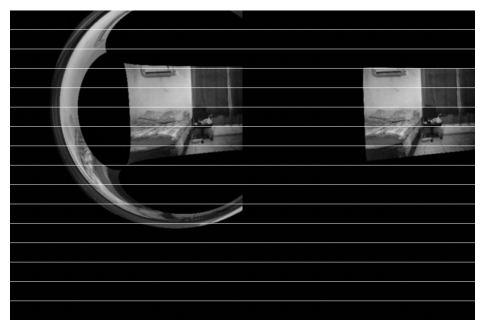

In [15]:
# Visualização da retificação
combined = np.hstack((rect_grayL, rect_grayR))
for i in range(0, combined.shape[0], 40):
    cv2.line(combined, (0,i), (combined.shape[1],i), 255, 1)

show(combined, gray=True)

In [16]:
# ==============================
# StereoSGBM
# ==============================

min_disp = 0
num_disp = 16*4

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=7,
    P1=8*1*7**2,
    P2=32*1*7**2,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=2,
    disp12MaxDiff=1
)

# matcher direito necessário para WLS
right_matcher = xip.createRightMatcher(stereo)

dispL = stereo.compute(rect_grayL, rect_grayR)
dispR = right_matcher.compute(rect_grayR, rect_grayL)

dispL = np.int16(dispL)
dispR = np.int16(dispR)

In [17]:
# ==============================
# TRUQUE 3 — WLS FILTER
# ==============================

wls = xip.createDisparityWLSFilter(stereo)
wls.setLambda(8000)
wls.setSigmaColor(1.5)

filtered_disp = wls.filter(dispL, rect_grayL, disparity_map_right=dispR)

disparity = filtered_disp.astype(np.float32) / 16.0

print("min:", np.min(disparity))
print("max:", np.max(disparity))

min: -1.0
max: 16.5625


In [18]:
# ==============================
# APLICAR ROI APENAS NO FINAL
# ==============================

x, y, w, h = common_roi
disparity_roi = disparity[y:y+h, x:x+w]

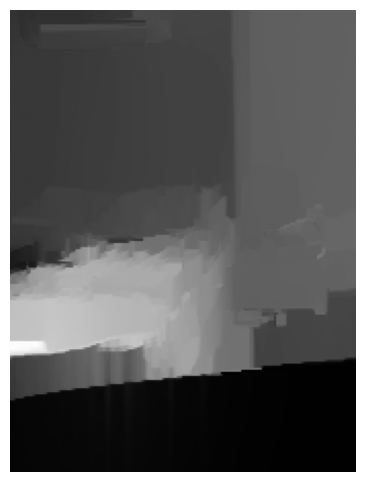

In [19]:
disp_vis = cv2.normalize(disparity_roi, None, 0, 255, cv2.NORM_MINMAX)
disp_vis = np.uint8(disp_vis)

show(disp_vis, gray=True)

In [20]:
print("original:", grayL.shape)
print("rectified:", rect_grayL.shape)
print("roiL:", roiL)
print("roiR:", roiR)

original: (480, 640)
rectified: (640, 480)
roiL: [[259.]
 [117.]
 [176.]
 [246.]]
roiR: [[265.]
 [121.]
 [169.]
 [226.]]
